# 02a · Inspect a simulation that was run earlier

Notebook **02** *runs* a simulation and dissects the live `run_log`. This notebook is its
companion: it **loads a run that was already saved to disk** — the kind `main.py` writes when
you run a setup from the terminal — and inspects it **without re-running anything**.

A terminal run

```bash
uv run python main.py run setups/three_node_chain --output data/three_node_chain
```

leaves behind a self-contained run directory:

| path | what it holds |
|---|---|
| `config/setup.yaml` + `config/catalog.csv` | verbatim inputs — enough to **rebuild the `Scenario`** |
| `config/scenario.json` | tiny provenance summary (seed, step count, node/edge counts) |
| `data/run_log.json` | the **full per-tick run log** — every snapshot notebook 02 inspects live |
| `data/{nodes,products,timeseries}.parquet` | tidy tables for quick querying |
| `reports/overview.png` | the regional supply/demand chart |

The whole act of "inspecting a saved run" is two lines: rebuild the scenario from the config
snapshot with `load_setup`, and read the run log back with `json.load`. Everything after that
is the **same `src/sim/inspect.py` helpers** notebook 02 uses — they don't care whether the
`run_log` came from `Runner.run()` or from disk.

> Like notebook 05a (analyze a saved *study*), this is pure post-hoc analysis. Re-point
> `RUN_DIR` at any `main.py run` output to inspect a different simulation.

In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and paths like `setups/three_node_chain`
# resolve no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · Point at a saved run

Set `RUN_DIR` to any directory `main.py run` produced. The default is
`data/three_node_chain`. If it isn't there yet, the cell **produces it once** by calling the
same CLI entry point you'd use from the terminal — so from here on we are genuinely loading a
run off disk, not running one in-process.

In [2]:
import main as cli

RUN_DIR = Path("data/three_node_chain")

# Produce the run once if it's missing — identical to running `main.py run` in a shell.
if not (RUN_DIR / "data" / "run_log.json").exists():
    print(f"{RUN_DIR} not found — generating it via the CLI (one-time)...")
    cli.main(["run", "setups/three_node_chain", "--output", str(RUN_DIR)])

assert (RUN_DIR / "data" / "run_log.json").is_file(), f"no run_log.json under {RUN_DIR}"
print("inspecting saved run:", RUN_DIR)

inspecting saved run: data/three_node_chain


### What's on disk

A run directory is portable — these are the only files we read. No engine, no policy code is
needed to inspect a finished run; just `pandas`, `json`, and the pure `inspect` helpers.

In [3]:
written = sorted(str(p.relative_to(RUN_DIR)) for p in RUN_DIR.rglob("*") if p.is_file())
print("files under", RUN_DIR, ":")
for f in written:
    print("  ", f)

# The provenance summary the exporter writes alongside the inputs.
scenario_meta = json.loads((RUN_DIR / "config" / "scenario.json").read_text())
print("\nconfig/scenario.json:")
for k, v in scenario_meta.items():
    print(f"  {k:12s} {v}")

files under data/three_node_chain :
   config/catalog.csv
   config/scenario.json
   config/setup.yaml
   data/nodes.parquet
   data/products.parquet
   data/run_log.json
   data/stores.parquet
   data/timeseries.parquet
   reports/overview.png

config/scenario.json:
  world_seed   42
  n_steps      30
  start_date   2024-01-01 00:00:00
  n_catalog    1
  n_nodes      3
  n_edges      2


### Load it: rebuild the scenario, read the run log

`load_setup(RUN_DIR / "config")` re-reads the verbatim `setup.yaml` + `catalog.csv` and
rebuilds the exact same `Scenario` the run used (same `world_seed`, so same derived per-node
seeds). The `run_log` itself comes straight from `run_log.json`. That's the whole loader.

In [4]:
from src.sim.setup_io import load_setup

scenario = load_setup(RUN_DIR / "config")
run_log = json.loads((RUN_DIR / "data" / "run_log.json").read_text())

print("rebuilt scenario nodes:",
      [(ni.node.id, type(ni.node).__name__) for ni in scenario.nodes])
print("run_log top-level keys:", list(run_log.keys()))
print(f"ran {run_log['n_steps']} ticks · {len(run_log['ticks'])} tick snapshots")

# Sanity: the rebuilt scenario and the saved provenance agree.
assert run_log["n_steps"] == scenario_meta["n_steps"]
assert len(scenario.nodes) == scenario_meta["n_nodes"]
print("scenario <-> run_log consistent ✓")

rebuilt scenario nodes: [('factory-1', 'FactoryNode'), ('shop-1', 'IntermediateNode'), ('sink-1', 'DemandSinkNode')]
run_log top-level keys: ['n_steps', 'ticks', 'global']
ran 30 ticks · 30 tick snapshots
scenario <-> run_log consistent ✓


## 2 · A scorecard for the finished run

Before charting, a one-glance summary of what this run *was* and how it *went*, computed
entirely from the loaded `run_log`. System equity is the sum of every node's worth
(`cash + inventory-at-cost + outstanding-at-cost`); its change from first to last tick is the
value the supply chain created. Lost sales come from the `unmet_demand` rejection entries.

In [5]:
from src.sim.inspect import node_equity

node_ids = [ni.node.id for ni in scenario.nodes]

# System equity at the first and last tick (sum over all nodes).
all_eq = pd.concat(
    node_equity(run_log, scenario, nid).assign(node_id=nid) for nid in node_ids
)
by_tick = all_eq.groupby("tick")["equity"].sum()
equity_start, equity_end = by_tick.iloc[0], by_tick.iloc[-1]

# Rejections / lost sales across the whole run.
rej = pd.DataFrame(
    [{**r, "tick": t["tick"]} for t in run_log["ticks"] for r in t["rejections"]]
)
lost_units = int(rej.loc[rej["reason"] == "unmet_demand", "qty_rejected"].sum()) if len(rej) else 0

regions = list(run_log["global"]["market_supply"].keys())

print(f"{'run directory':22s}: {RUN_DIR}")
print(f"{'ticks':22s}: {run_log['n_steps']}")
print(f"{'nodes':22s}: {len(node_ids)}  ({', '.join(node_ids)})")
print(f"{'products':22s}: {len(scenario.catalog)}")
print(f"{'regions':22s}: {', '.join(regions)}")
print(f"{'system equity (start)':22s}: {equity_start:,.0f}")
print(f"{'system equity (end)':22s}: {equity_end:,.0f}")
print(f"{'value created':22s}: {equity_end - equity_start:,.0f}")
print(f"{'rejection entries':22s}: {len(rej)}")
print(f"{'lost-sale units':22s}: {lost_units}")

run directory         : data/three_node_chain
ticks                 : 30
nodes                 : 3  (factory-1, shop-1, sink-1)
products              : 1
regions               : US
system equity (start) : 2,250
system equity (end)   : 6,370
value created         : 4,120
rejection entries     : 1
lost-sale units       : 6


## 3 · Per-node metrics over time

`node_timeseries_df` flattens the run log into one row per `(tick, node)`. The same four
small-multiples as notebook 02 — except every number here was read off disk.

columns: ['tick', 'node_id', 'node_type', 'region', 'level', 'cash', 'inventory_total', 'pending_total', 'orders_total']


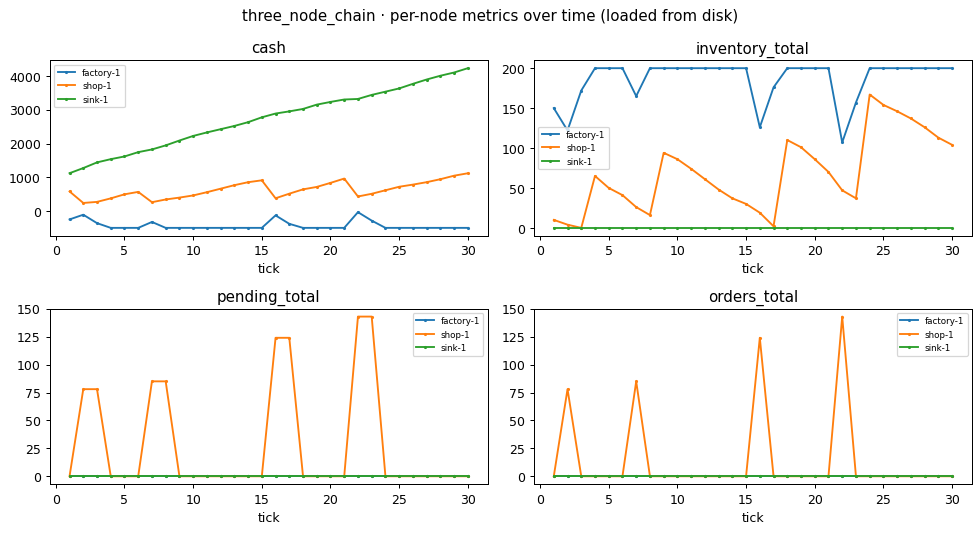

,tick,node_id,node_type,region,level,cash,inventory_total,pending_total,orders_total
0,1,factory-1,FactoryNode,US,None,-250.0,150,0,0
1,1,shop-1,IntermediateNode,US,None,580.0,10,0,0
2,1,sink-1,DemandSinkNode,US,None,1120.0,0,0,0
3,2,factory-1,FactoryNode,US,None,-110.0,122,0,0
4,2,shop-1,IntermediateNode,US,None,238.0,4,78,78


In [6]:
from src.sim.inspect import node_timeseries_df

ts = node_timeseries_df(run_log, scenario)
print("columns:", list(ts.columns))

metrics = ["cash", "inventory_total", "pending_total", "orders_total"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, metric in zip(axes.ravel(), metrics):
    for nid, g in ts.groupby("node_id"):
        ax.plot(g["tick"], g[metric], label=nid, marker=".", ms=3)
    ax.set_title(metric)
    ax.set_xlabel("tick")
    ax.legend(fontsize=7)
fig.suptitle(f"{RUN_DIR.name} · per-node metrics over time (loaded from disk)")
plt.tight_layout()
plt.show()
ts.head()

## 4 · Where the value sits — and where it ended up

Two complementary views of `node_equity`. **Left:** system-wide equity over time, decomposed
into cash / inventory-at-cost / outstanding-at-cost — the black line is total system worth.
**Right:** each node's *final* equity. In a chain, the demand sink accumulates the new cash it
generates, while upstream nodes hold their value as stock and in-transit orders.

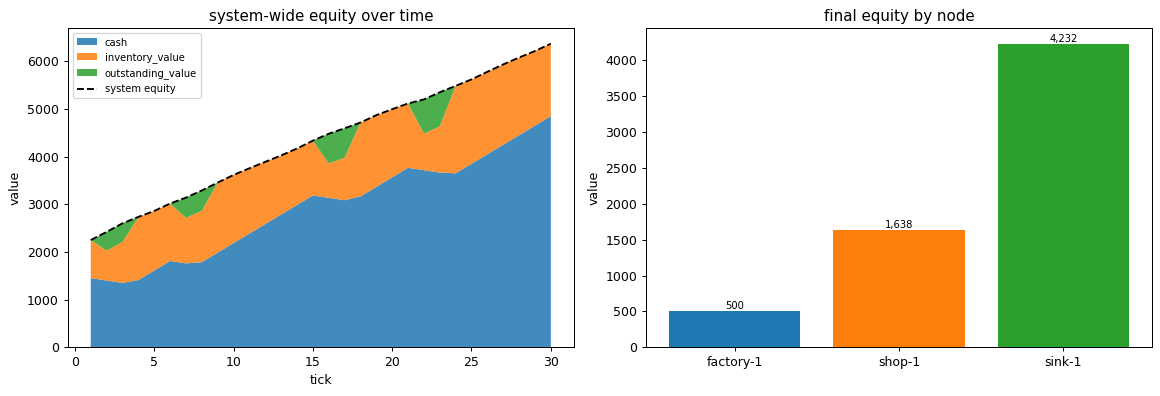

In [7]:
sys_eq = all_eq.groupby("tick")[
    ["cash", "inventory_value", "outstanding_value", "equity"]
].sum()
final_eq = (
    all_eq[all_eq["tick"] == all_eq["tick"].max()]
    .set_index("node_id")["equity"]
    .reindex(node_ids)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

parts = ["cash", "inventory_value", "outstanding_value"]
ax1.stackplot(sys_eq.index, [sys_eq[p] for p in parts], labels=parts, alpha=0.85)
ax1.plot(sys_eq.index, sys_eq["equity"], color="black", lw=1.5, ls="--", label="system equity")
ax1.set_title("system-wide equity over time")
ax1.set_xlabel("tick")
ax1.set_ylabel("value")
ax1.legend(loc="upper left", fontsize=8)

colors = plt.cm.tab10(range(len(final_eq)))
ax2.bar(final_eq.index, final_eq.values, color=colors)
ax2.set_title("final equity by node")
ax2.set_ylabel("value")
for i, v in enumerate(final_eq.values):
    ax2.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## 5 · The shared world & per-product detail

`global_timeseries_df` recovers the regional market supply/demand the run played against, and
`per_product_df` breaks one node down to per-`(tick, product)` inventory, pending, and orders.

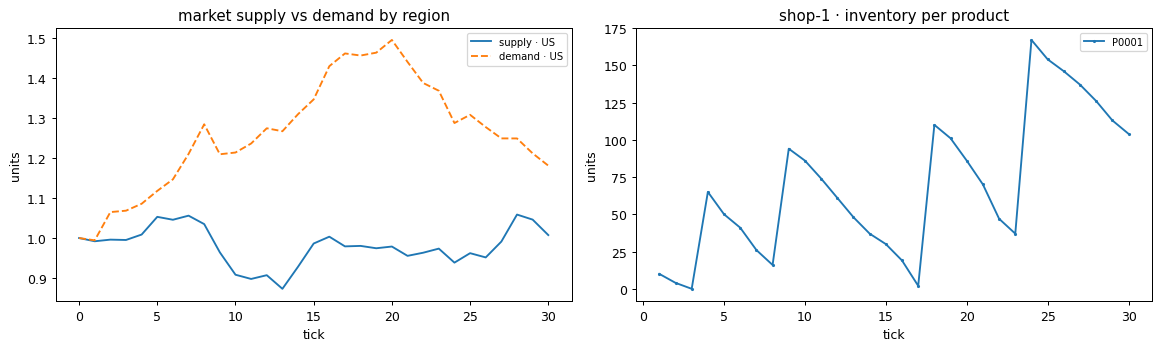

,tick,node_id,pid,inventory,pending,orders
0,1,shop-1,P0001,10,0,0
1,2,shop-1,P0001,4,78,78
2,3,shop-1,P0001,0,78,0
3,4,shop-1,P0001,65,0,0
4,5,shop-1,P0001,50,0,0


In [8]:
from src.sim.inspect import global_timeseries_df, per_product_df

gts = global_timeseries_df(run_log)
supply_cols = [c for c in gts.columns if c.startswith("market_supply_")]
regions = [c.removeprefix("market_supply_") for c in supply_cols]

# Pick an intermediate node (holds real per-product inventory) for the per-product view.
inter = next(
    (ni.node.id for ni in scenario.nodes if type(ni.node).__name__ == "IntermediateNode"),
    node_ids[0],
)
pp = per_product_df(run_log, scenario, inter)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for region in regions:
    ax1.plot(gts["tick"], gts[f"market_supply_{region}"], label=f"supply · {region}")
    ax1.plot(gts["tick"], gts[f"market_demand_{region}"], label=f"demand · {region}", ls="--")
ax1.set_title("market supply vs demand by region")
ax1.set_xlabel("tick")
ax1.set_ylabel("units")
ax1.legend(fontsize=8)

for pid, g in pp.groupby("pid"):
    ax2.plot(g["tick"], g["inventory"], label=pid, marker=".", ms=3)
ax2.set_title(f"{inter} · inventory per product")
ax2.set_xlabel("tick")
ax2.set_ylabel("units")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()
pp.head()

## 6 · Rejections & lost sales — the run's health

Every saved tick carries a `rejections` list: one entry per order the engine could **not**
fill in full, tagged with the binding constraint (`insufficient_stock`, `insufficient_cash`,
`insufficient_capacity`, `below_min_order`, `no_offer`). Entries with `reason="unmet_demand"`
are the true **lost sales** — demand at a sink no feasible supplier could meet. This is the
first place to look when a finished run underperformed.

total rejection entries: 1
reasons: {'unmet_demand': 1}
lost-sale (unmet_demand) units: 6


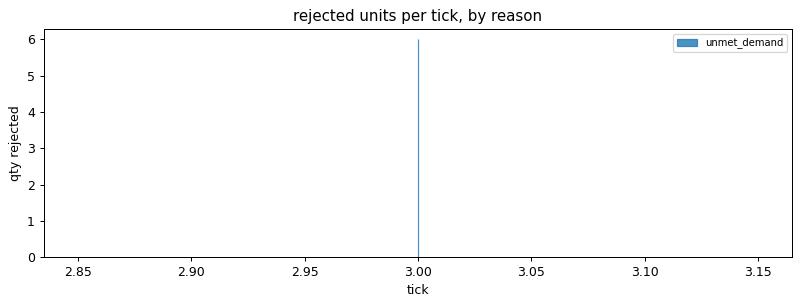

,tick,buyer_id,supplier_id,pid,qty_requested,qty_filled,qty_rejected,reason
0,3,sink-1,None,P0001,10,4,6,unmet_demand


In [9]:
print("total rejection entries:", len(rej))
if len(rej):
    print("reasons:", rej["reason"].value_counts().to_dict())
    print("lost-sale (unmet_demand) units:", lost_units)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    by_reason = rej.groupby(["tick", "reason"])["qty_rejected"].sum().unstack(fill_value=0)
    by_reason.plot(kind="area", stacked=True, ax=ax, alpha=0.8)
    ax.set_title("rejected units per tick, by reason")
    ax.set_xlabel("tick")
    ax.set_ylabel("qty rejected")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    display(rej.head())
else:
    print("no rejections this run — every order was filled in full.")

## 7 · Trust the artifacts — reconcile parquet against the run log

A saved run ships both the raw `run_log.json` and tidy `*.parquet` tables. They are written
from the same source, so they should agree exactly. This is a cheap integrity check you can
run on any run directory before you trust its tables: re-read `timeseries.parquet` and confirm
its per-node inventory matches what `per_product_df` reconstructs from the run log.

In [10]:
ts_pq = pd.read_parquet(RUN_DIR / "data" / "timeseries.parquet")
print("timeseries.parquet:", ts_pq.shape[0], "rows ·", list(ts_pq.columns)[:5], "...")

# Nodes that actually carry per-product inventory rows in the parquet table.
nodes_in_pq = sorted(ts_pq["store_id"].unique())

# Rebuild the same (node, tick, product, inventory) grid from the run log.
from_log = pd.concat(
    per_product_df(run_log, scenario, nid).assign(store_id=nid) for nid in nodes_in_pq
)[["store_id", "tick", "pid", "inventory"]]

merged = ts_pq.merge(
    from_log,
    left_on=["store_id", "simulation_step", "product_id"],
    right_on=["store_id", "tick", "pid"],
    suffixes=("_parquet", "_runlog"),
)
max_diff = (merged["inventory_parquet"] - merged["inventory_runlog"]).abs().max()
print(f"rows reconciled : {len(merged)}")
print(f"max |Δinventory|: {max_diff}  ->", "MATCH ✓" if max_diff == 0 else "MISMATCH ✗")
assert max_diff == 0, "parquet and run_log disagree on inventory"

timeseries.parquet: 30 rows · ['simulation_step', 'simulation_date', 'store_id', 'product_id', 'inventory'] ...
rows reconciled : 30
max |Δinventory|: 0  -> MATCH ✓


### The exported overview chart

`reports/overview.png` is the regional supply/demand figure the exporter rendered at save
time — embed the written file directly, no re-plotting.

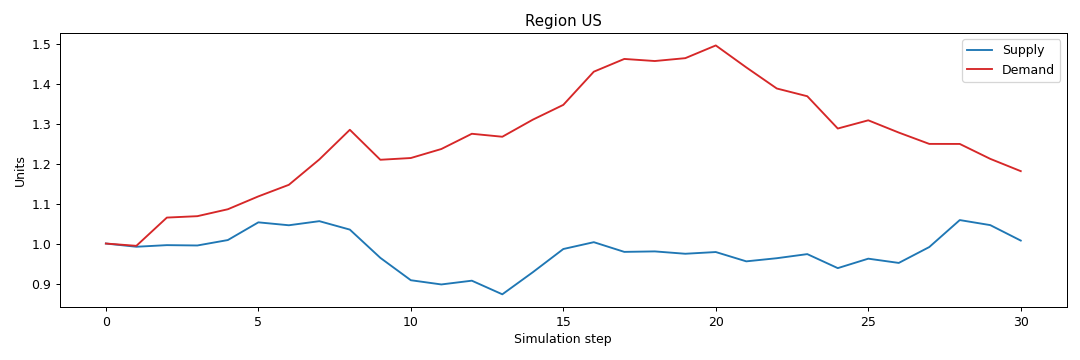

In [11]:
from IPython.display import Image

Image(filename=str(RUN_DIR / "reports" / "overview.png"))

## 8 · Business metrics scorecard (from disk)

`business_metrics` derives the four operational KPIs directly from the saved run log — no re-running needed.  One row per selling node, plus a system-wide `_system` roll-up.


In [12]:
from src.sim.inspect import flow_frame, node_timeseries_df
from src.sim.metrics import business_metrics

ff = flow_frame(run_log)
ts_df = node_timeseries_df(run_log, scenario)
kpis = business_metrics(ff, ts_df, scenario)
kpis

,node_id,service_level,stockout_rate,inventory_turnover,mean_price_pct_of_msrp


### 8b · Profit decomposition + Δcash reconciliation

`profit_decomposition` breaks the cash flow of each `IntermediateNode` into four components — `revenue`, `order_cost`, `holding_cost`, `order_fees` — all derived from the saved run log and the node rates on disk. The resulting `net_profit` reconciles to Δcash by construction (ADR 0019 Rule 3).

In [13]:
from src.sim.inspect import closing_inventory_frame, purchase_frame as pf_builder
from src.sim.metrics import profit_decomposition

cif   = closing_inventory_frame(run_log)
pf    = pf_builder(run_log)
decomp = profit_decomposition(ff, pf, cif, scenario)
decomp

,node_id,revenue,order_cost,holding_cost,order_fees,net_profit
0,shop-1,0.0,0.0,103.05,0.0,-103.05


In [14]:
# Reconciliation check: net_profit vs Δcash for each node.
from src.sim.runner import build_world

sim0 = build_world(scenario)
reconcile_rows = []
for _, row in decomp.iterrows():
    nid = row["node_id"]
    initial_cash = sim0.nodes[nid].cash
    final_cash   = run_log["ticks"][-1]["node_cash"][nid]
    delta_cash   = final_cash - initial_cash
    reconcile_rows.append({
        "node_id":    nid,
        "net_profit": row["net_profit"],
        "delta_cash": delta_cash,
        "gap":        abs(row["net_profit"] - delta_cash),
    })

import pandas as pd
pd.DataFrame(reconcile_rows)

,node_id,net_profit,delta_cash,gap
0,shop-1,-103.05,618.0,721.05


## Where to next

- Re-point `RUN_DIR` at any other `main.py run` output — a multi-supplier setup like
  `setups/two_factories_two_shops`, or a large LLM-generated world from notebook 01 — and
  re-run this notebook top to bottom. It's written against the run-directory *schema*, so it
  adapts to whatever it finds.
- Produce a fresh run to inspect here:
  `uv run python main.py run setups/two_factories_two_shops --output data/two_factories`.
- `business_metrics` (see § 8 above) computes the operational KPI scorecard directly
  from the saved run log — no re-running needed, even from a bare run directory.

| notebook | topic |
|---|---|
| **02** | run a simulation & inspect every output — *the live companion to this one* |
| **04** | compare the four textbook policies under Common Random Numbers |
| **05** / **05a** | tune a policy with Optuna / analyze a saved study from disk |
| **06** / **06a** | train a PPO agent / analyze a saved trained agent |